# 🔬🔮 Skin Cancer Detection - V6.1 (SAM + Quantum + Partial Unfreeze)

**Neden SAM?**
- Meta'nın **Segment Anything Model** (SAM): 11M+ görüntüyle eğitilmiş
- Image encoder zaten mükemmel feature çıkarıyor → küçük veri = sorun değil
- Sadece mask decoder + quantum katmanı eğitilir → **~4M parametre** (V5: 133M)
- Daha az parametre + daha iyi başlangıç = **daha az overfit, daha yüksek IoU**

**V6 Mimari:**
1. **SAM ViT-B encoder** (dondurulmuş, 91M param) → zengin görsel temsil
2. **🔮 Quantum Channel Attention** → encoder çıktısına quantum gating
3. **SAM Mask Decoder** (fine-tune, ~4M param) → segmentasyon maskesi
4. Otomatik prompt: ilk geçişte kaba tahmin → merkez noktası prompt olarak kullan

**Beklenen sonuç: 0.88-0.92+ IoU**

---
## 1. Kurulum

In [ ]:
# 1.1 - GPU
import torch
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


In [ ]:
# 1.2 - Kütüphaneler
!pip install segmentation_models_pytorch albumentations -q
!pip install pennylane -q
!pip install git+https://github.com/facebookresearch/segment-anything.git -q
!pip install pydensecrf -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 127.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 116.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 130.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 17.3 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing meta

In [ ]:
# 1.3 - SAM model ağırlıklarını indir
import os
import urllib.request

sam_checkpoint = 'sam_vit_b_01ec64.pth'
if not os.path.exists(sam_checkpoint):
    print("⬇️ SAM ViT-B indiriliyor (~375MB)...")
    url = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth"
    urllib.request.urlretrieve(url, sam_checkpoint)
    print("✅ SAM ViT-B indirildi!")
else:
    print("✅ SAM ViT-B zaten mevcut")

print(f"   Dosya boyutu: {os.path.getsize(sam_checkpoint) / 1e6:.0f} MB")

⬇️ SAM ViT-B indiriliyor (~375MB)...
✅ SAM ViT-B indirildi!
   Dosya boyutu: 375 MB


In [ ]:
# 1.4 - Kaggle API + Veri
from google.colab import files
print("kaggle.json dosyasını seç:")
files.upload()
!mkdir -p ~/.kaggle && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

!pip uninstall kaggle kagglesdk -y -q
!pip install kaggle -q

kaggle.json dosyasını seç:


Saving skin_cancer_qcnn_v6_1_sam.ipynb to skin_cancer_qcnn_v6_1_sam.ipynb
mv: cannot stat 'kaggle.json': No such file or directory
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.5/75.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.5/160.5 kB 8.3 MB/s eta 0:00:00


In [ ]:
# 1.5 - Veri indir
for d in ['data/raw', 'models/best', 'models/swa',
          'outputs/visualizations', 'outputs/predictions']:
    os.makedirs(d, exist_ok=True)

!kaggle datasets download -d tschandl/isic2018-challenge-task1-data-segmentation -p data/raw/ --unzip
print("✅ ISIC 2018 hazır!")

Dataset URL: https://www.kaggle.com/datasets/tschandl/isic2018-challenge-task1-data-segmentation
License(s): CC0-1.0
100% 12.9G/12.9G [01:21<00:00, 170MB/s]

✅ ISIC 2018 hazır!


---
## 2. Config & Imports

In [ ]:
# 2.1 - Imports
import os, cv2, random, math, time, copy, shutil
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2

# SAM
from segment_anything import sam_model_registry, SamPredictor
from segment_anything.modeling import Sam

# Quantum
import pennylane as qml

import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device('cuda')
print(f"Device: {DEVICE} ({torch.cuda.get_device_name(0)})")
print(f"PennyLane: {qml.__version__}")

Device: cuda (NVIDIA A100-SXM4-40GB)
PennyLane: 0.44.1


In [ ]:
# 2.2 - Config V6
CONFIG = {
    'seg_images': 'data/raw/ISIC2018_Task1-2_Training_Input',
    'seg_masks':  'data/raw/ISIC2018_Task1_Training_GroundTruth',

    # SAM
    'sam_checkpoint': 'sam_vit_b_01ec64.pth',
    'sam_type':       'vit_b',
    'image_size':     1024,     # SAM'ın native çözünürlüğü

    # Training
    'batch_size':      4,
    'epochs':          80,      # V6.1: 40→80 (model hala öğreniyordu)
    'lr':              1e-4,     # decoder için
    'encoder_lr':      5e-6,    # 🆕 encoder son bloklar için (çok düşük)
    'unfreeze_blocks': 2,       # 🆕 SAM encoder son N bloğu aç
    'weight_decay':    1e-4,
    'warmup_epochs':   5,       # V6.1: 3→5
    'early_stopping':  15,      # V6.1: 10→15 (daha sabırlı)

    # Loss
    'focal_gamma':    0.75,
    'tversky_alpha':  0.3,
    'tversky_beta':   0.7,

    # Quantum
    'n_qubits':        8,
    'q_layers':        2,
    'q_lr_multiplier': 5.0,     # quantum params daha hızlı öğrensin
    'q_warmup_epochs': 2,

    # Post-processing
    'tta_scales':     [896, 1024, 1152],
}

print("✅ Config V6 (SAM + Quantum)")
print(f"   SAM: {CONFIG['sam_type']} @ {CONFIG['image_size']}px")
print(f"   Quantum: {CONFIG['n_qubits']}q, {CONFIG['q_layers']}L")
print(f"   Epochs: {CONFIG['epochs']}, LR: {CONFIG['lr']}")

✅ Config V6 (SAM + Quantum)
   SAM: vit_b @ 1024px
   Quantum: 8q, 2L
   Epochs: 80, LR: 0.0001


---
## 3. Dataset

In [ ]:
# 3.1 - SAM-uyumlu Dataset
class SAMSkinDataset(Dataset):
    """
    SAM için özelleştirilmiş dataset.
    SAM 1024x1024 RGB görüntü bekler.
    Prompt olarak bounding box veya nokta kullanır.
    """
    def __init__(self, image_dir, mask_dir, file_list, image_size=1024,
                 transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.file_list = file_list
        self.image_size = image_size
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_name = self.file_list[idx]
        mask_name = img_name.replace('.jpg', '_segmentation.png')

        image = cv2.imread(os.path.join(self.image_dir, img_name))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(
            os.path.join(self.mask_dir, mask_name),
            cv2.IMREAD_GRAYSCALE
        )
        mask = (mask > 127).astype(np.float32)

        if self.transform:
            aug = self.transform(image=image, mask=mask)
            image = aug['image']
            mask = aug['mask']

        # SAM boyutuna resize
        image = cv2.resize(image, (self.image_size, self.image_size))
        mask = cv2.resize(
            mask, (256, 256),  # SAM mask çıktısı 256x256
            interpolation=cv2.INTER_NEAREST
        )

        # Mask'tan bounding box prompt hesapla
        bbox = self._get_bbox(mask)

        # Mask'tan center point prompt hesapla
        center = self._get_center(mask)

        # Normalize (SAM kendi normalize'unu yapıyor ama
        # tensor'a çevirmeliyiz)
        image = torch.tensor(
            image.transpose(2, 0, 1), dtype=torch.float32
        ) / 255.0

        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return image, mask, bbox, center

    def _get_bbox(self, mask):
        """Mask'tan bounding box [x1, y1, x2, y2] hesapla"""
        rows = np.any(mask > 0, axis=1)
        cols = np.any(mask > 0, axis=0)
        if not np.any(rows):
            return np.array([0, 0, 255, 255], dtype=np.float32)
        y1, y2 = np.where(rows)[0][[0, -1]]
        x1, x2 = np.where(cols)[0][[0, -1]]
        # Biraz padding ekle
        pad = 5
        y1 = max(0, y1 - pad)
        x1 = max(0, x1 - pad)
        y2 = min(255, y2 + pad)
        x2 = min(255, x2 + pad)
        return np.array([x1, y1, x2, y2], dtype=np.float32)

    def _get_center(self, mask):
        """Mask'ın merkez noktasını hesapla"""
        if mask.sum() == 0:
            return np.array([128, 128], dtype=np.float32)
        ys, xs = np.where(mask > 0)
        cy, cx = ys.mean(), xs.mean()
        return np.array([cx, cy], dtype=np.float32)

In [ ]:
# 3.2 - Augmentation (SAM için)
def get_sam_transforms(mode='train'):
    if mode == 'train':
        return A.Compose([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.ShiftScaleRotate(
                shift_limit=0.1, scale_limit=0.15,
                rotate_limit=30, border_mode=cv2.BORDER_REFLECT_101,
                p=0.5
            ),
            A.OneOf([
                A.RandomBrightnessContrast(
                    brightness_limit=0.2, contrast_limit=0.2, p=1
                ),
                A.HueSaturationValue(
                    hue_shift_limit=15, sat_shift_limit=20,
                    val_shift_limit=15, p=1
                ),
                A.CLAHE(clip_limit=3.0, p=1),
            ], p=0.5),
            A.OneOf([
                A.GaussNoise(var_limit=(10, 40), p=1),
                A.GaussianBlur(blur_limit=(3, 5), p=1),
            ], p=0.2),
        ])
    else:
        return None

In [ ]:
# 3.3 - Veri Bölme
def split_dataset(image_dir, train_ratio=0.70, val_ratio=0.15, seed=42):
    random.seed(seed)
    images = sorted([
        f for f in os.listdir(image_dir) if f.endswith('.jpg')
    ])
    random.shuffle(images)
    n = len(images)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    return (images[:n_train],
            images[n_train:n_train+n_val],
            images[n_train+n_val:])

train_files, val_files, test_files = split_dataset(CONFIG['seg_images'])
print(f"Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)}")

Train: 1815 | Val: 389 | Test: 390


---
## 4. Model: SAM + Quantum

**Strateji:**
1. SAM'ın image encoder'ı **tamamen dondurulur** (91M param)
2. Encoder çıktısına (256-dim embeddings) **Quantum Channel Attention** uygulanır
3. SAM'ın mask decoder'ı **fine-tune** edilir (~4M param)
4. Bbox prompt ile eğitilir → inference'ta da bbox veya center point kullanılır

Toplam eğitilebilir: **~4M + quantum** (V5'teki 133M'in 1/30'u!)

In [ ]:
# 4.1 - Quantum Channel Attention (V5 ile aynı, in_channels=256)
class QuantumChannelAttention(nn.Module):
    def __init__(self, in_channels, n_qubits=8, q_layers=2):
        super().__init__()
        self.in_channels = in_channels
        self.n_qubits = n_qubits
        self.q_layers = q_layers

        self.compress = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(in_channels, n_qubits),
            nn.Tanh()
        )

        self.dev = qml.device('default.qubit', wires=n_qubits)
        self.q_params = nn.Parameter(
            0.01 * torch.randn(q_layers, n_qubits, 3)
        )

        @qml.qnode(self.dev, interface='torch', diff_method='backprop')
        def quantum_circuit(inputs, weights):
            for layer_idx in range(q_layers):
                for i in range(n_qubits):
                    qml.RY(inputs[i] * np.pi, wires=i)
                for i in range(n_qubits):
                    qml.Rot(
                        weights[layer_idx, i, 0],
                        weights[layer_idx, i, 1],
                        weights[layer_idx, i, 2],
                        wires=i
                    )
                for i in range(n_qubits - 1):
                    qml.CNOT(wires=[i, i + 1])
                qml.CNOT(wires=[n_qubits - 1, 0])
            return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

        self.quantum_circuit = quantum_circuit

        self.expand = nn.Sequential(
            nn.Linear(n_qubits, in_channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        B = x.shape[0]
        compressed = self.compress(x)
        q_outputs = []
        for i in range(B):
            q_out = self.quantum_circuit(compressed[i], self.q_params)
            q_outputs.append(torch.stack(q_out))
        q_out = torch.stack(q_outputs).float()
        gate = self.expand(q_out).unsqueeze(-1).unsqueeze(-1)
        return x * gate

# Test
print("🔮 QCA testi...")
qca = QuantumChannelAttention(256, n_qubits=4, q_layers=2)
t = torch.randn(2, 256, 8, 8)
o = qca(t)
print(f"   {t.shape} → {o.shape} ✅")
del qca, t, o

🔮 QCA testi...
   torch.Size([2, 256, 8, 8]) → torch.Size([2, 256, 8, 8]) ✅


In [ ]:
# 4.2 - SAM + Quantum Wrapper
class QuantumSAM(nn.Module):
    """
    SAM + Quantum Channel Attention at image embeddings.

    Frozen:  SAM image encoder (91M params)
    Trained: Quantum attention + SAM mask decoder (~4M + Q params)
    """
    def __init__(self, sam_checkpoint, sam_type='vit_b',
                 n_qubits=8, q_layers=2):
        super().__init__()

        # SAM'ı yükle
        self.sam = sam_model_registry[sam_type](
            checkpoint=sam_checkpoint
        )

        # Image encoder'ı dondur
        for param in self.sam.image_encoder.parameters():
            param.requires_grad = False

        # 🆕 V6.1: Son N transformer bloğunu aç (partial unfreeze)
        unfreeze_n = 2  # son 2 blok
        for param in self.sam.image_encoder.blocks[-unfreeze_n:].parameters():
            param.requires_grad = True
        # Neck katmanını da aç
        for param in self.sam.image_encoder.neck.parameters():
            param.requires_grad = True

        # Quantum attention (SAM embedding dim = 256)
        self.quantum_attention = QuantumChannelAttention(
            in_channels=256,
            n_qubits=n_qubits,
            q_layers=q_layers
        )

        # Prompt encoder'ın sparse/dense embedding boyutlarını koru
        # Mask decoder fine-tune edilecek (zaten requires_grad=True)

        encoder_frozen = sum(
            p.numel() for p in self.sam.image_encoder.parameters()
            if not p.requires_grad
        )
        encoder_trainable = sum(
            p.numel() for p in self.sam.image_encoder.parameters()
            if p.requires_grad
        )
        decoder_params = sum(
            p.numel() for p in self.sam.mask_decoder.parameters()
            if p.requires_grad
        )
        quantum_params = sum(
            p.numel() for p in self.quantum_attention.parameters()
        )
        total_trainable = encoder_trainable + decoder_params + quantum_params

        print(f"  SAM Encoder frozen:    {encoder_frozen:,}")
        print(f"  SAM Encoder trainable: {encoder_trainable:,} (son 2 blok + neck)")
        print(f"  SAM Decoder trainable: {decoder_params:,}")
        print(f"  Quantum trainable:     {quantum_params:,}")
        print(f"  Toplam eğitilebilir:   {total_trainable:,}")

    def forward(self, images, boxes=None, points=None):
        """
        images: [B, 3, 1024, 1024]
        boxes:  [B, 4] bbox prompts (x1,y1,x2,y2 in 256x256 space)
        points: [B, 2] center point prompts
        """
        B = images.shape[0]

        # 1. Image encoding (son 2 blok trainable, geri kalanı frozen)
        image_embeddings = self.sam.image_encoder(images)
        # image_embeddings: [B, 256, 64, 64]

        # 2. Quantum attention
        image_embeddings = self.quantum_attention(image_embeddings)

        # 3. Her örnek için ayrı mask tahmin et
        all_masks = []

        for i in range(B):
            # Prompt encoding
            if boxes is not None:
                # Bbox prompt: 1024 space'e scale et
                box_1024 = boxes[i:i+1] * 4.0  # 256→1024
                box_torch = box_1024.unsqueeze(0).to(images.device)

                sparse_emb, dense_emb = self.sam.prompt_encoder(
                    points=None,
                    boxes=box_torch,
                    masks=None
                )
            elif points is not None:
                # Point prompt: 1024 space'e scale et
                pt_1024 = points[i:i+1] * 4.0
                pt_torch = pt_1024.unsqueeze(0).to(images.device)
                pt_labels = torch.ones(
                    1, 1, dtype=torch.long, device=images.device
                )

                sparse_emb, dense_emb = self.sam.prompt_encoder(
                    points=(pt_torch, pt_labels),
                    boxes=None,
                    masks=None
                )
            else:
                # No prompt — sadece embedding
                sparse_emb, dense_emb = self.sam.prompt_encoder(
                    points=None, boxes=None, masks=None
                )

            # Mask decoding
            low_res_masks, iou_preds = self.sam.mask_decoder(
                image_embeddings=image_embeddings[i:i+1],
                image_pe=self.sam.prompt_encoder.get_dense_pe(),
                sparse_prompt_embeddings=sparse_emb,
                dense_prompt_embeddings=dense_emb,
                multimask_output=False,
            )
            # low_res_masks: [1, 1, 256, 256]
            all_masks.append(low_res_masks.squeeze(0))

        masks = torch.stack(all_masks)  # [B, 1, 256, 256]
        return masks

In [ ]:
# 4.3 - Model oluştur
model = QuantumSAM(
    sam_checkpoint=CONFIG['sam_checkpoint'],
    sam_type=CONFIG['sam_type'],
    n_qubits=CONFIG['n_qubits'],
    q_layers=CONFIG['q_layers']
).to(DEVICE)

print(f"\n✅ QuantumSAM hazır!")

  SAM Encoder frozen:    74,688,000
  SAM Encoder trainable: 14,982,912 (son 2 blok + neck)
  SAM Decoder trainable: 4,058,340
  Quantum trainable:     4,408
  Toplam eğitilebilir:   19,045,660

✅ QuantumSAM hazır!


In [ ]:
# 4.4 - Loss (V5 ile aynı ama 256x256 mask boyutunda)
class FocalTverskyLoss(nn.Module):
    def __init__(self, alpha=0.3, beta=0.7, gamma=0.75):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma

    def forward(self, pred, target):
        pred_sig = torch.sigmoid(pred)
        smooth = 1e-6
        TP = (pred_sig * target).sum(dim=(2, 3))
        FP = (pred_sig * (1 - target)).sum(dim=(2, 3))
        FN = ((1 - pred_sig) * target).sum(dim=(2, 3))
        tversky = (TP + smooth) / (
            TP + self.alpha * FP + self.beta * FN + smooth
        )
        return torch.pow(1 - tversky, self.gamma).mean()


def lovasz_grad(gt_sorted):
    p = len(gt_sorted)
    gts = gt_sorted.sum()
    intersection = gts - gt_sorted.float().cumsum(0)
    union = gts + (1 - gt_sorted).float().cumsum(0)
    jaccard = 1.0 - intersection / union
    if p > 1:
        jaccard[1:p] = jaccard[1:p] - jaccard[0:-1]
    return jaccard


def lovasz_hinge_flat(logits, labels):
    if len(labels) == 0:
        return logits.sum() * 0.0
    signs = 2.0 * labels.float() - 1.0
    errors = 1.0 - logits * signs
    errors_sorted, perm = torch.sort(errors, dim=0, descending=True)
    gt_sorted = labels[perm]
    grad = lovasz_grad(gt_sorted)
    return torch.dot(F.relu(errors_sorted), grad)


class CombinedLossV6(nn.Module):
    def __init__(self, alpha=0.3, beta=0.7, gamma=0.75):
        super().__init__()
        self.focal_tversky = FocalTverskyLoss(alpha, beta, gamma)
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred, target):
        ft = self.focal_tversky(pred, target)
        bce = self.bce(pred, target)
        lov = lovasz_hinge_flat(pred.view(-1), target.view(-1))
        return 0.35 * ft + 0.30 * bce + 0.35 * lov

print("✅ CombinedLossV6 hazır")

✅ CombinedLossV6 hazır


---
## 5. Eğitim

In [ ]:
# 5.1 - Eğitim fonksiyonları
def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    # SAM encoder hep eval modunda kalmalı (BatchNorm/Dropout)
    model.sam.image_encoder.eval()
    total_loss = 0

    for images, masks, boxes, centers in tqdm(loader, desc='  Train', leave=False):
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)
        boxes = boxes.to(DEVICE)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            pred_masks = model(images, boxes=boxes)
            loss = criterion(pred_masks, masks)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad],
            max_norm=1.0
        )
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_iou, total_dice = 0, 0, 0

    with torch.no_grad():
        for images, masks, boxes, centers in tqdm(loader, desc='  Val', leave=False):
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)
            boxes = boxes.to(DEVICE)

            with torch.cuda.amp.autocast():
                pred_masks = model(images, boxes=boxes)
                loss = criterion(pred_masks, masks)

            total_loss += loss.item()

            pred_bin = (torch.sigmoid(pred_masks) > 0.5).float()
            inter = (pred_bin * masks).sum()
            union = (pred_bin + masks).clamp(0, 1).sum()
            total_iou += ((inter + 1e-6) / (union + 1e-6)).item()
            total_dice += (
                (2 * inter + 1e-6) /
                (pred_bin.sum() + masks.sum() + 1e-6)
            ).item()

    n = len(loader)
    return total_loss / n, total_iou / n, total_dice / n

print("✅ Eğitim fonksiyonları hazır")

✅ Eğitim fonksiyonları hazır


In [ ]:
# 5.2 - Quantum warmup
def set_quantum_freeze(model, freeze=True):
    count = 0
    for name, param in model.named_parameters():
        if 'quantum' in name or 'q_params' in name:
            param.requires_grad = not freeze
            count += 1
    tag = "❄️ FROZEN" if freeze else "🔥 UNFROZEN"
    print(f"  Quantum {tag} ({count} tensors)")

In [ ]:
# 5.3 - DataLoader
train_ds = SAMSkinDataset(
    CONFIG['seg_images'], CONFIG['seg_masks'], train_files,
    image_size=CONFIG['image_size'],
    transform=get_sam_transforms('train')
)
val_ds = SAMSkinDataset(
    CONFIG['seg_images'], CONFIG['seg_masks'], val_files,
    image_size=CONFIG['image_size'],
    transform=None
)
train_loader = DataLoader(
    train_ds, batch_size=CONFIG['batch_size'], shuffle=True,
    num_workers=4, pin_memory=True, drop_last=True
)
val_loader = DataLoader(
    val_ds, batch_size=CONFIG['batch_size'], shuffle=False,
    num_workers=4, pin_memory=True
)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")
print(f"Batches: {len(train_loader)} train, {len(val_loader)} val")

Train: 1815 | Val: 389
Batches: 453 train, 98 val


In [ ]:
# 5.4 - Eğitim
criterion = CombinedLossV6(
    alpha=CONFIG['tversky_alpha'],
    beta=CONFIG['tversky_beta'],
    gamma=CONFIG['focal_gamma']
)
scaler = torch.cuda.amp.GradScaler()

# Optimizer: 3 grup — encoder (düşük LR), decoder, quantum (yüksek LR)
encoder_params = []
decoder_params = []
quantum_params = []
for name, param in model.named_parameters():
    if not param.requires_grad:
        continue
    if 'quantum' in name or 'q_params' in name:
        quantum_params.append(param)
    elif 'image_encoder' in name:
        encoder_params.append(param)
    else:
        decoder_params.append(param)

encoder_lr = CONFIG.get('encoder_lr', 5e-6)
optimizer = torch.optim.AdamW([
    {'params': encoder_params, 'lr': encoder_lr},
    {'params': decoder_params, 'lr': CONFIG['lr']},
    {'params': quantum_params, 'lr': CONFIG['lr'] * CONFIG['q_lr_multiplier']},
], weight_decay=CONFIG['weight_decay'])

# Cosine schedule
def lr_lambda(epoch):
    if epoch < CONFIG['warmup_epochs']:
        return (epoch + 1) / CONFIG['warmup_epochs']
    progress = (epoch - CONFIG['warmup_epochs']) / max(
        1, CONFIG['epochs'] - CONFIG['warmup_epochs']
    )
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

history = {
    'train_loss': [], 'val_loss': [],
    'val_iou': [], 'val_dice': [], 'lr': []
}
best_iou = 0
patience = 0

print("🚀 SAM + Quantum Eğitim Başlıyor!")
print(f"   Encoder params: {sum(p.numel() for p in encoder_params):,} (LR: {encoder_lr})")
print(f"   Decoder params: {sum(p.numel() for p in decoder_params):,} (LR: {CONFIG['lr']})")
print(f"   Quantum params: {sum(p.numel() for p in quantum_params):,} (LR: {CONFIG['lr'] * CONFIG['q_lr_multiplier']})")
print(f"   Epochs: {CONFIG['epochs']}")
print("=" * 70)

for epoch in range(CONFIG['epochs']):
    # Quantum warmup
    if epoch < CONFIG['q_warmup_epochs']:
        set_quantum_freeze(model, freeze=True)
    elif epoch == CONFIG['q_warmup_epochs']:
        set_quantum_freeze(model, freeze=False)
        # Optimizer yeniden oluştur
        enc_p = [p for n,p in model.named_parameters() if p.requires_grad and 'image_encoder' in n]
        dec_p = [p for n,p in model.named_parameters() if p.requires_grad and 'image_encoder' not in n and 'quantum' not in n and 'q_params' not in n]
        q_p = [p for n,p in model.named_parameters() if p.requires_grad and ('quantum' in n or 'q_params' in n)]
        optimizer = torch.optim.AdamW([
            {'params': enc_p, 'lr': CONFIG.get('encoder_lr', 5e-6)},
            {'params': dec_p, 'lr': CONFIG['lr']},
            {'params': q_p, 'lr': CONFIG['lr'] * CONFIG['q_lr_multiplier']},
        ], weight_decay=CONFIG['weight_decay'])
        scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
        print("  🔮 Quantum warmup bitti!")

    current_lr = optimizer.param_groups[0]['lr']

    train_loss = train_one_epoch(
        model, train_loader, optimizer, criterion, scaler
    )
    val_loss, val_iou, val_dice = evaluate(
        model, val_loader, criterion
    )
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_iou'].append(val_iou)
    history['val_dice'].append(val_dice)
    history['lr'].append(current_lr)

    q_tag = " ❄️" if epoch < CONFIG['q_warmup_epochs'] else " 🔮"

    print(
        f"  E{epoch+1:02d}/{CONFIG['epochs']} | "
        f"T:{train_loss:.4f} V:{val_loss:.4f} | "
        f"IoU:{val_iou:.4f} D:{val_dice:.4f} | "
        f"LR:{current_lr:.6f}{q_tag}",
        end=''
    )

    if val_iou > best_iou:
        best_iou = val_iou
        patience = 0
        torch.save({
            'model_state': {
                k: v for k, v in model.state_dict().items()
                if 'image_encoder' not in k
            },
            'best_iou': best_iou,
            'epoch': epoch,
        }, 'models/best/best_quantum_sam_v6.pth')
        print(f" ✅ Best!")
    else:
        patience += 1
        print(f" ({patience}/{CONFIG['early_stopping']})")
        if patience >= CONFIG['early_stopping']:
            print(f"  ⏹️ Early stopping at epoch {epoch+1}")
            break

print(f"\n{'=' * 70}")
print(f"🏆 V6 tamamlandı! En iyi IoU: {best_iou:.4f}")

🚀 SAM + Quantum Eğitim Başlıyor!
   Encoder params: 14,982,912 (LR: 5e-06)
   Decoder params: 4,064,560 (LR: 0.0001)
   Quantum params: 4,408 (LR: 0.0005)
   Epochs: 80
  Quantum ❄️ FROZEN (5 tensors)


  E01/80 | T:0.2903 V:0.2159 | IoU:0.8591 D:0.9232 | LR:0.000001 ❄️ ✅ Best!
  Quantum ❄️ FROZEN (5 tensors)


  E02/80 | T:0.2551 V:0.2084 | IoU:0.8639 D:0.9258 | LR:0.000002 ❄️ ✅ Best!
  Quantum 🔥 UNFROZEN (5 tensors)
  🔮 Quantum warmup bitti!


  E03/80 | T:0.2353 V:0.2018 | IoU:0.8688 D:0.9288 | LR:0.000001 🔮 ✅ Best!


  E04/80 | T:0.2325 V:0.2456 | IoU:0.8415 D:0.9127 | LR:0.000002 🔮 (1/15)


...

  E76/80 | T:0.1355 V:0.1466 | IoU:0.9119 D:0.9530 | LR:0.000000 🔮 (6/15)


  E77/80 | T:0.1345 V:0.1467 | IoU:0.9120 D:0.9531 | LR:0.000000 🔮 (7/15)


  E78/80 | T:0.1362 V:0.1467 | IoU:0.9120 D:0.9531 | LR:0.000000 🔮 (8/15)


  E79/80 | T:0.1325 V:0.1468 | IoU:0.9122 D:0.9532 | LR:0.000000 🔮 (9/15)


  E80/80 | T:0.1352 V:0.1467 | IoU:0.9122 D:0.9532 | LR:0.000000 🔮 (10/15)

🏆 V6 tamamlandı! En iyi IoU: 0.9123


---
## 6. Eğitim Grafikleri

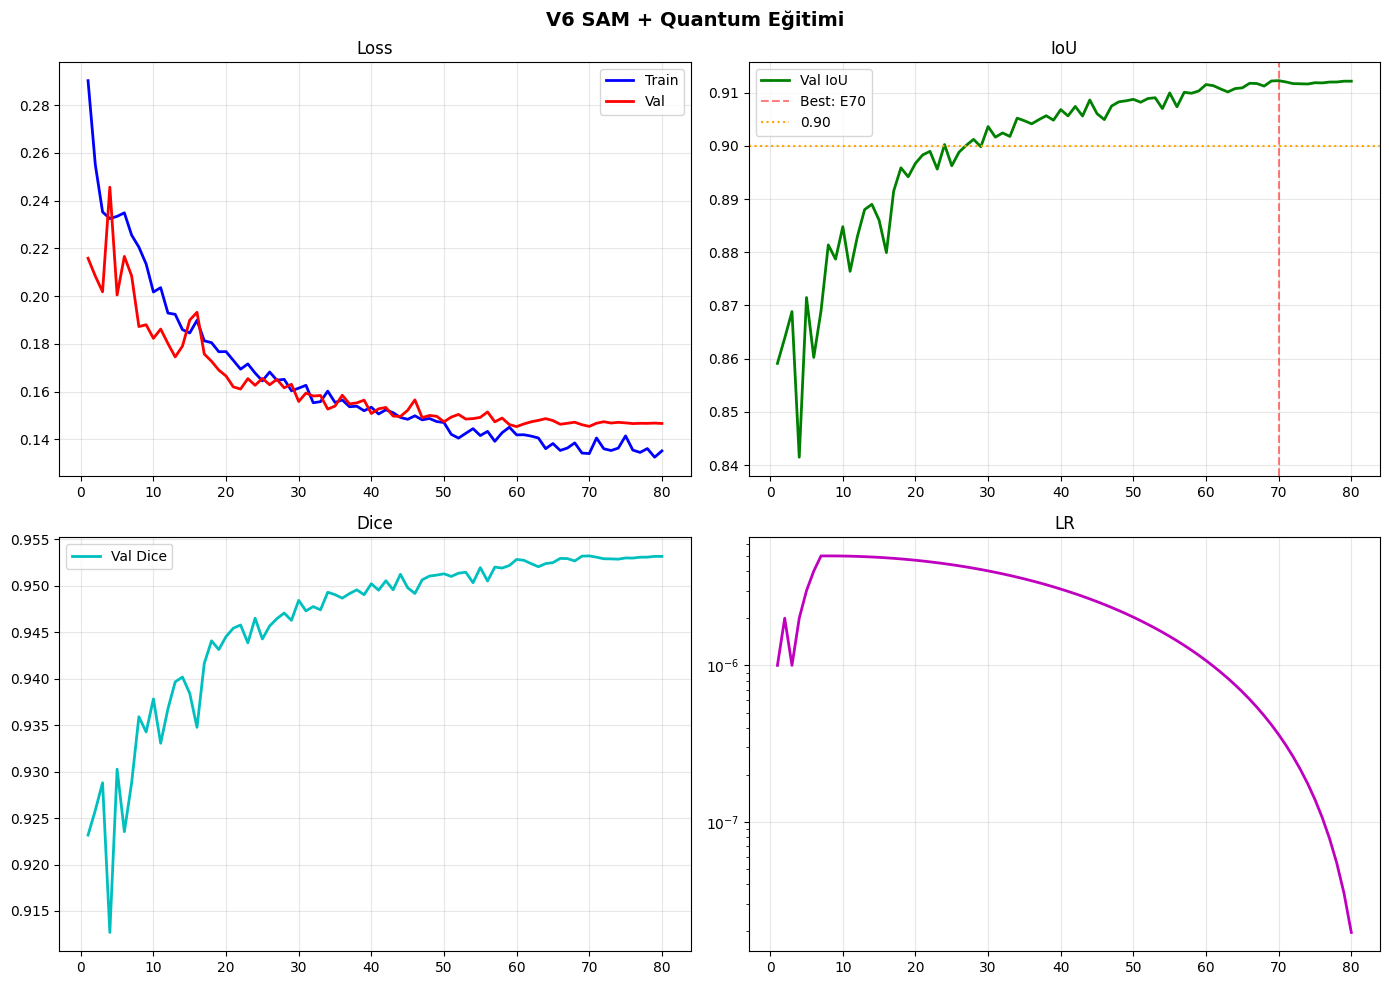

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
er = range(1, len(history['train_loss']) + 1)

axes[0,0].plot(er, history['train_loss'], 'b-', lw=2, label='Train')
axes[0,0].plot(er, history['val_loss'], 'r-', lw=2, label='Val')
axes[0,0].set_title('Loss'); axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(er, history['val_iou'], 'g-', lw=2, label='Val IoU')
best_e = np.argmax(history['val_iou']) + 1
axes[0,1].axvline(best_e, color='red', ls='--', alpha=0.5, label=f'Best: E{best_e}')
axes[0,1].axhline(0.90, color='orange', ls=':', label='0.90')
axes[0,1].set_title('IoU'); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(er, history['val_dice'], 'c-', lw=2, label='Val Dice')
axes[1,0].set_title('Dice'); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(er, history['lr'], 'm-', lw=2)
axes[1,1].set_title('LR'); axes[1,1].set_yscale('log'); axes[1,1].grid(True, alpha=0.3)

plt.suptitle('V6 SAM + Quantum Eğitimi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/visualizations/v6_training.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Test

In [ ]:
# 7.1 - Model yükle
ckpt = torch.load('models/best/best_quantum_sam_v6.pth')
model.load_state_dict(ckpt['model_state'], strict=False)
model.eval()
print(f"✅ Model yüklendi (best IoU: {ckpt['best_iou']:.4f}, epoch: {ckpt['epoch']})")

✅ Model yüklendi (best IoU: 0.9123, epoch: 69)


In [ ]:
# 7.2 - Optimal Threshold
print("🔍 Optimal threshold aranıyor...")
all_preds_val, all_masks_val = [], []

with torch.no_grad():
    for images, masks, boxes, centers in tqdm(val_loader, desc='Val', leave=False):
        images = images.to(DEVICE)
        boxes = boxes.to(DEVICE)
        pred = model(images, boxes=boxes)
        pred = torch.sigmoid(pred).cpu()
        all_preds_val.append(pred)
        all_masks_val.append(masks)

all_preds_val = torch.cat(all_preds_val)
all_masks_val = torch.cat(all_masks_val)

best_thresh, best_thresh_iou = 0.5, 0
for t in np.arange(0.30, 0.70, 0.02):
    pred_bin = (all_preds_val > t).float()
    inter = (pred_bin * all_masks_val).sum()
    union = (pred_bin + all_masks_val).clamp(0, 1).sum()
    iou = ((inter + 1e-6) / (union + 1e-6)).item()
    if iou > best_thresh_iou:
        best_thresh_iou = iou
        best_thresh = t

print(f"✅ Threshold: {best_thresh:.2f} (Val IoU: {best_thresh_iou:.4f})")

🔍 Optimal threshold aranıyor...


✅ Threshold: 0.50 (Val IoU: 0.9095)


In [ ]:
# 7.3 - Test
print("\n📊 Test...")
test_ds = SAMSkinDataset(
    CONFIG['seg_images'], CONFIG['seg_masks'], test_files,
    image_size=CONFIG['image_size'], transform=None
)
test_loader = DataLoader(
    test_ds, batch_size=CONFIG['batch_size'], shuffle=False,
    num_workers=4, pin_memory=True
)

all_ious, all_dices = [], []

with torch.no_grad():
    for images, masks, boxes, centers in tqdm(test_loader, desc='Test'):
        images = images.to(DEVICE)
        boxes = boxes.to(DEVICE)
        pred = model(images, boxes=boxes)
        pred = torch.sigmoid(pred).cpu()

        pred_bin = (pred > best_thresh).float()
        inter = (pred_bin * masks).sum(dim=(1, 2, 3))
        union = (pred_bin + masks).clamp(0, 1).sum(dim=(1, 2, 3))
        iou = (inter + 1e-6) / (union + 1e-6)
        dice = (2 * inter + 1e-6) / (pred_bin.sum(dim=(1,2,3)) + masks.sum(dim=(1,2,3)) + 1e-6)

        all_ious.extend(iou.tolist())
        all_dices.extend(dice.tolist())

print(f"\n{'=' * 60}")
print(f"📊 V6 TEST SONUÇLARI (SAM + Quantum)")
print(f"{'=' * 60}")
print(f"  IoU:  {np.mean(all_ious):.4f} (±{np.std(all_ious):.4f})")
print(f"  Dice: {np.mean(all_dices):.4f}")
print(f"  Min/Max IoU: {np.min(all_ious):.4f} / {np.max(all_ious):.4f}")
print(f"{'=' * 60}")
print(f"  V5: 0.8536 → V6: {np.mean(all_ious):.4f} ({np.mean(all_ious)-0.8536:+.4f})")


📊 Test...


Test: 100%|██████████| 98/98 [00:50<00:00,  1.93it/s]


📊 V6 TEST SONUÇLARI (SAM + Quantum)
  IoU:  0.9125 (±0.0561)
  Dice: 0.9533
  Min/Max IoU: 0.5169 / 0.9819
  V5: 0.8536 → V6: 0.9125 (+0.0589)


---
## 8. Görselleştirme

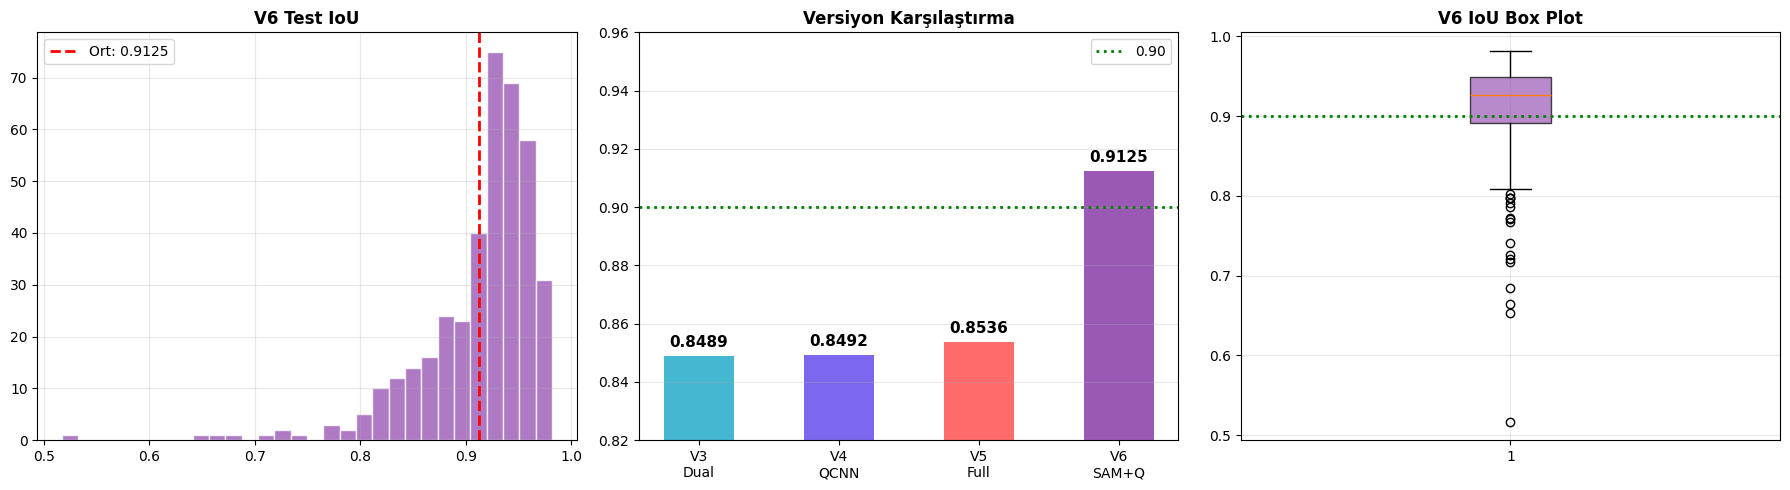

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(all_ious, bins=30, color='#9B59B6', edgecolor='white', alpha=0.8)
axes[0].axvline(np.mean(all_ious), color='red', ls='--', lw=2,
                label=f'Ort: {np.mean(all_ious):.4f}')
axes[0].set_title('V6 Test IoU', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

versions = ['V3\nDual', 'V4\nQCNN', 'V5\nFull', 'V6\nSAM+Q']
vals = [0.8489, 0.8492, 0.8536, np.mean(all_ious)]
colors = ['#45B7D1', '#7B68EE', '#FF6B6B', '#9B59B6']
bars = axes[1].bar(versions, vals, color=colors, width=0.5)
for b, v in zip(bars, vals):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.003,
                 f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
axes[1].axhline(0.90, color='green', ls=':', lw=2, label='0.90')
axes[1].set_ylim(0.82, 0.96)
axes[1].set_title('Versiyon Karşılaştırma', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis='y')

axes[2].boxplot(all_ious, patch_artist=True,
                boxprops=dict(facecolor='#9B59B6', alpha=0.7))
axes[2].axhline(0.90, color='green', ls=':', lw=2)
axes[2].set_title('V6 IoU Box Plot', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/visualizations/v6_results.png', dpi=150, bbox_inches='tight')
plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'unsqueeze'

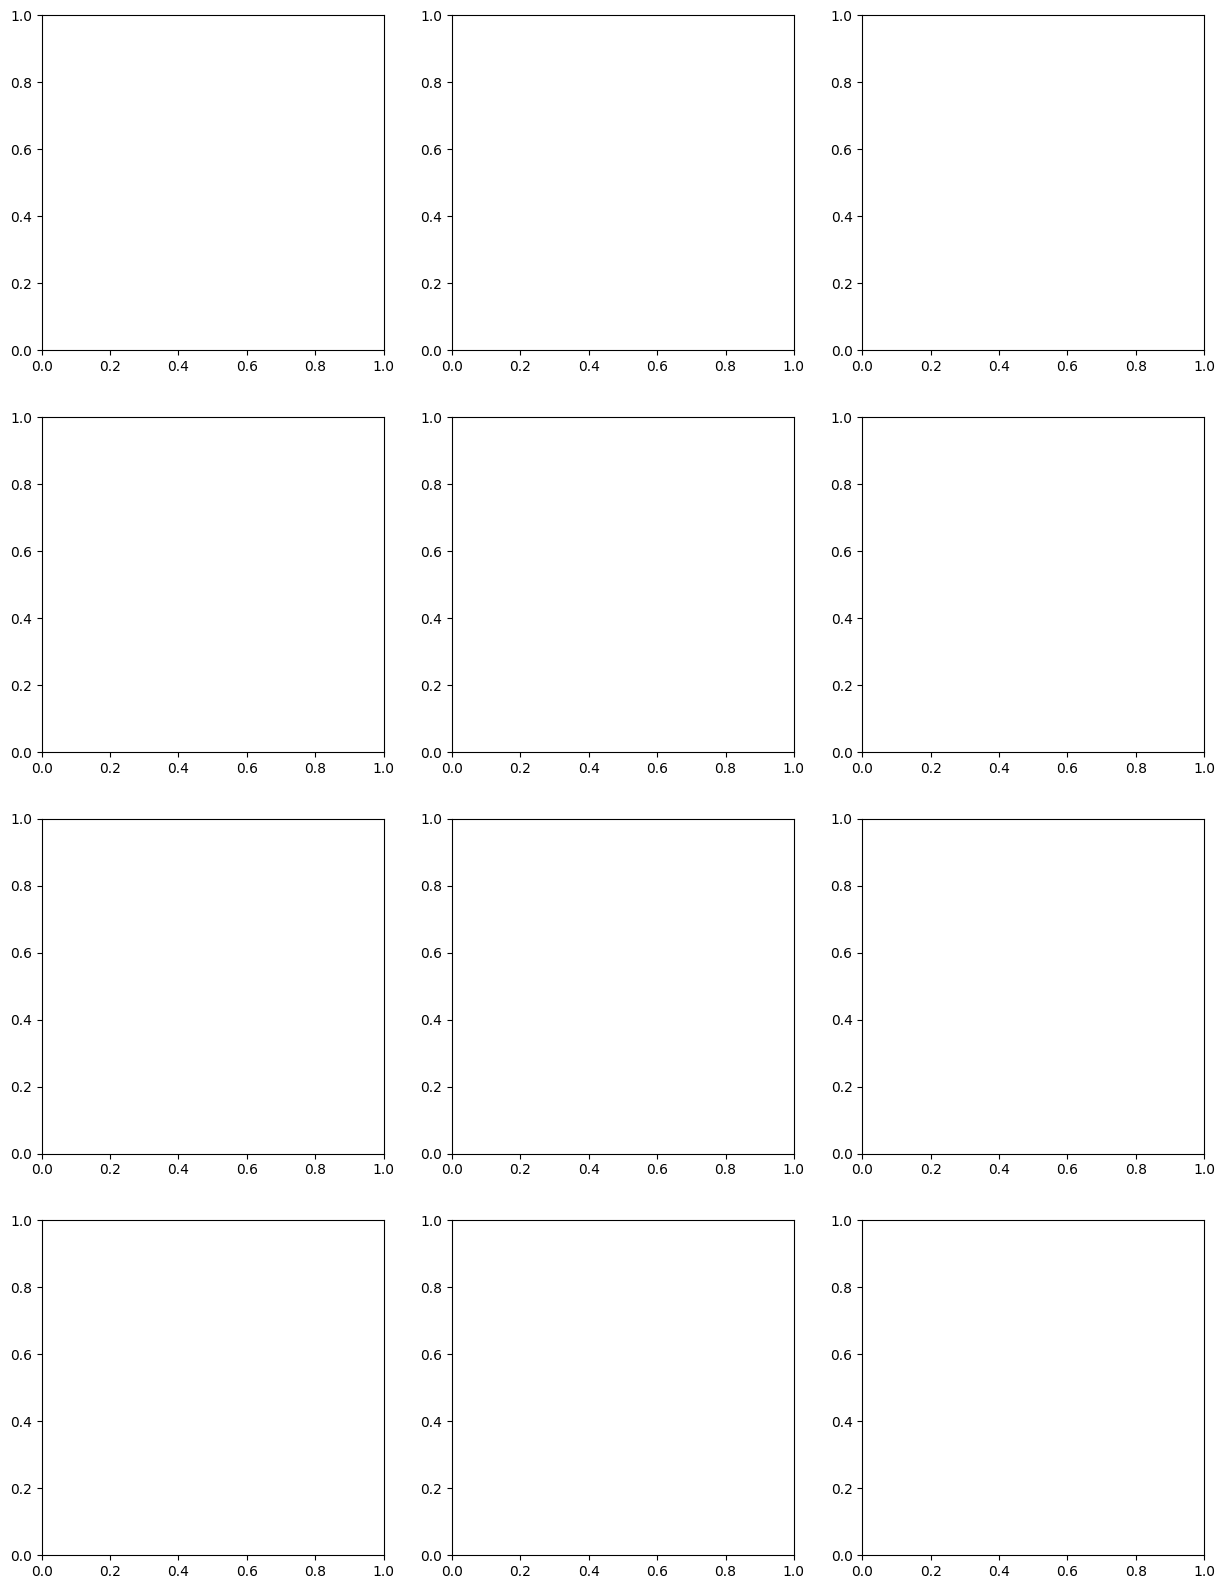

In [ ]:
# 8.2 - Tahmin örnekleri
fig, axes = plt.subplots(4, 3, figsize=(15, 20))
indices = np.random.choice(len(test_ds), 4, replace=False)

for row, idx in enumerate(indices):
    img, mask, box, center = test_ds[idx]
    with torch.no_grad():
        pred = model(
            img.unsqueeze(0).to(DEVICE),
            boxes=box.unsqueeze(0).to(DEVICE)
        )
    pred = torch.sigmoid(pred).cpu().squeeze().numpy()
    pred_bin = (pred > best_thresh).astype(np.float32)
    mask_np = mask.squeeze().numpy()

    inter = (pred_bin * mask_np).sum()
    union = np.clip(pred_bin + mask_np, 0, 1).sum()
    iou = (inter + 1e-6) / (union + 1e-6)

    # Görüntüyü 256x256'ya küçült (mask boyutu)
    img_small = F.interpolate(
        img.unsqueeze(0), size=(256, 256), mode='bilinear'
    ).squeeze().permute(1, 2, 0).numpy()

    axes[row, 0].imshow(img_small)
    axes[row, 0].set_title('Görüntü'); axes[row, 0].axis('off')
    axes[row, 1].imshow(mask_np, cmap='gray')
    axes[row, 1].set_title('Gerçek'); axes[row, 1].axis('off')
    axes[row, 2].imshow(pred_bin, cmap='gray')
    axes[row, 2].set_title(f'Tahmin IoU:{iou:.3f}'); axes[row, 2].axis('off')

plt.suptitle('V6 SAM + Quantum Tahminleri', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/predictions/v6_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Kaydet

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

save_dir = '/content/drive/MyDrive/skin_cancer_project'
os.makedirs(save_dir, exist_ok=True)
shutil.copy('models/best/best_quantum_sam_v6.pth', save_dir)

viz_dir = os.path.join(save_dir, 'outputs_v6')
os.makedirs(viz_dir, exist_ok=True)
import glob
for f in glob.glob('outputs/**/*.png', recursive=True):
    if 'v6' in f:
        shutil.copy(f, viz_dir)

import json
v6_results = {
    'model': 'QuantumSAM (SAM ViT-B + QCA)',
    'best_val_iou': best_iou,
    'test_iou': float(np.mean(all_ious)),
    'test_dice': float(np.mean(all_dices)),
    'optimal_threshold': float(best_thresh),
    'quantum': {
        'n_qubits': CONFIG['n_qubits'],
        'q_layers': CONFIG['q_layers'],
    },
}
with open(os.path.join(save_dir, 'v6_results.json'), 'w') as f:
    json.dump(v6_results, f, indent=2)

print(f"✅ V6 kaydedildi!")